# 8. Relative Analysis

In [1]:
import os,sys
print(os.getcwd())
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
print("Project root directory:", project_root)
sys.path.append(project_root)

/home/zhaolei/meal-rec-ai/preprocess
Project root directory: /home/zhaolei/meal-rec-ai


In [2]:
from analysis.relative import prepare_association_data
# 加载数据
from utils.data import root_path
import pandas as pd
import warnings

print("\n加载数据...")
positive_samples = pd.read_csv(f'{root_path}daily_meal_plan_positive.csv')
negative_samples = pd.read_csv(f'{root_path}daily_meal_plan_negative.csv')

# 合并数据
positive_samples['label'] = 1
negative_samples['label'] = 0
data = pd.concat([positive_samples, negative_samples], axis=0, ignore_index=True)

# 准备分析数据
analysis_data = prepare_association_data(data)

疾病与营养素关联性分析

加载数据...

分析数据规模: 226758 条正例记录
疾病标签数: 8
营养素数: 16


In [3]:
from analysis.relative import point_biserial_correlation
# 1. 点二列相关分析
corr_df = point_biserial_correlation(analysis_data)


1. 点二列相关系数分析

Top 15 最强关联 (疾病 ↔ 营养素):
       Disease    Nutrient  Correlation  P_Value  Significant
  osteoporosis   vitamin_d     0.956433      0.0         True
   over_weight       sugar    -0.771740      0.0         True
blood_pressure      sodium    -0.731002      0.0         True
   over_weight   vitamin_c    -0.567738      0.0         True
blood_pressure   potassium     0.558964      0.0         True
  osteoporosis     calcium     0.527290      0.0         True
blood_pressure  folic_acid    -0.512956      0.0         True
  osteoporosis vitamin_b12     0.496995      0.0         True
      diabetes        carb    -0.474994      0.0         True
blood_pressure        iron    -0.356102      0.0         True
 opioid_misuse     protein     0.354451      0.0         True
        anemia  folic_acid     0.316911      0.0         True
   over_weight     calcium    -0.300962      0.0         True
   over_weight     protein     0.285345      0.0         True
 opioid_misuse  phosphorus     

In [4]:
from analysis.relative import nutrient_difference_analysis
# 2. 营养素差异分析
diff_df = nutrient_difference_analysis(analysis_data)


2. 患病/非患病群体营养素差异分析

显著差异的疾病-营养素对: 123

Top 15 最大差异 (效应量):
       Disease    Nutrient  Diseased_Mean  Non_Diseased_Mean   Difference       P_Value   Cohen_d  Significant
  osteoporosis   vitamin_d      20.402687           0.549292    19.853396  0.000000e+00  9.029639         True
  osteoporosis     calcium    1655.535026         773.391160   882.143867  0.000000e+00  2.981518         True
      diabetes        carb     210.749196         380.379634  -169.630438  0.000000e+00 -2.101240         True
   over_weight       sugar      26.928977         182.529525  -155.600548  0.000000e+00 -2.052373         True
blood_pressure      sodium    1295.873581        3783.214689 -2487.341108  0.000000e+00 -1.963509         True
        anemia  folic_acid     576.598458         223.217833   353.380625  0.000000e+00  1.817923         True
  osteoporosis vitamin_b12       8.092271           2.064308     6.027963  0.000000e+00  1.811543         True
blood_pressure   potassium    3872.571815        2791

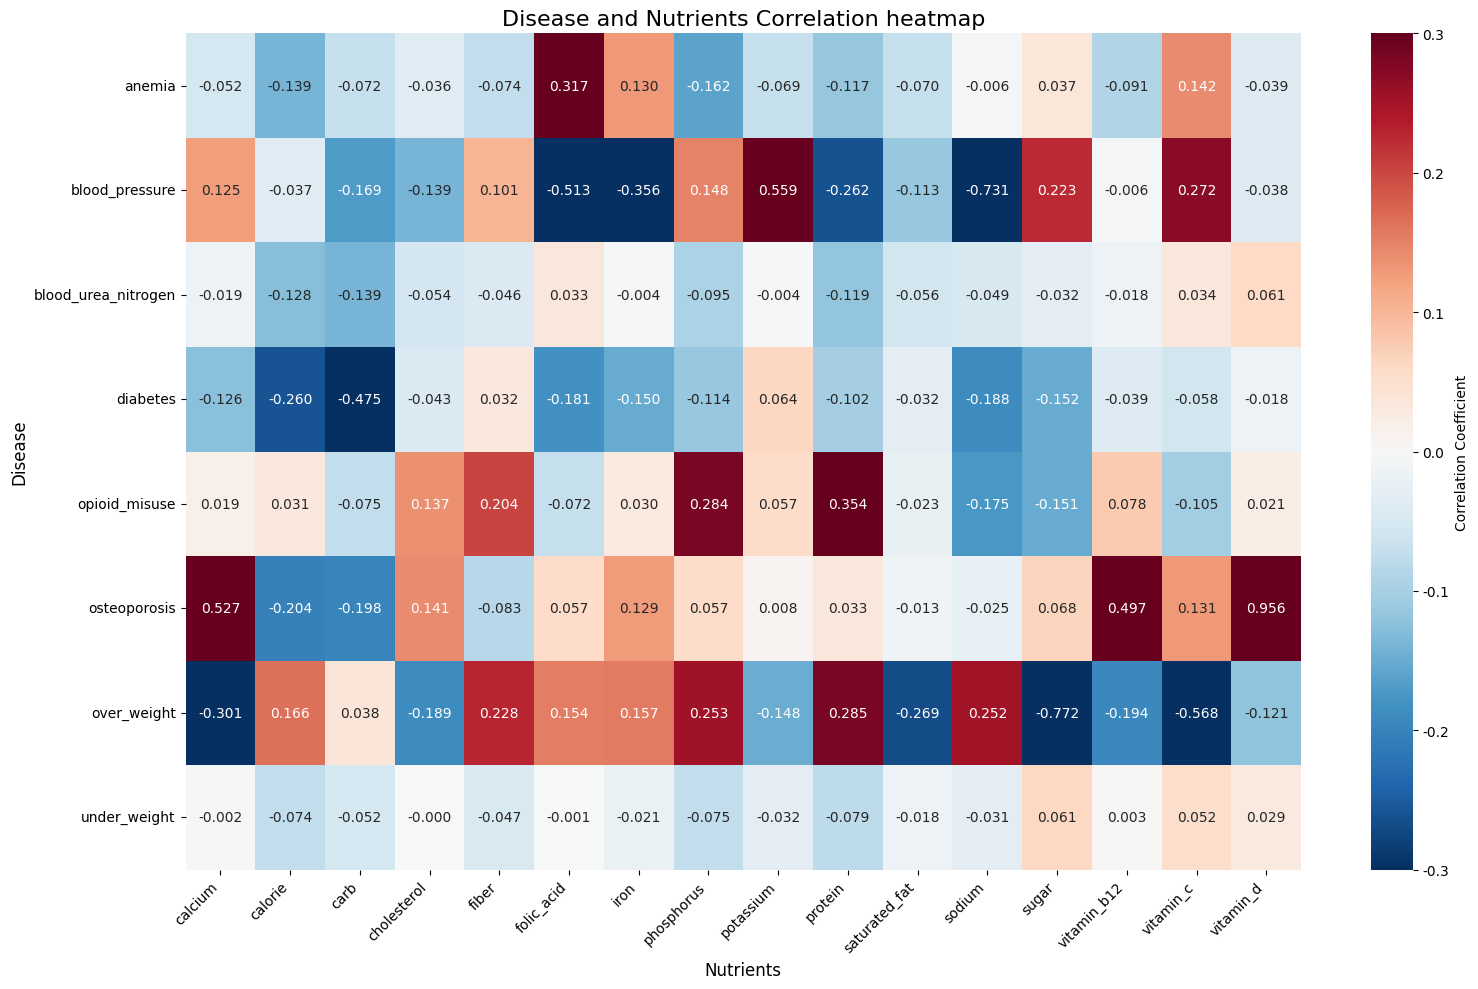

In [5]:
from analysis.relative import plot_correlation_heatmap
# 3. 绘制热力图
plot_correlation_heatmap(corr_df)


3. 疾病聚类分析


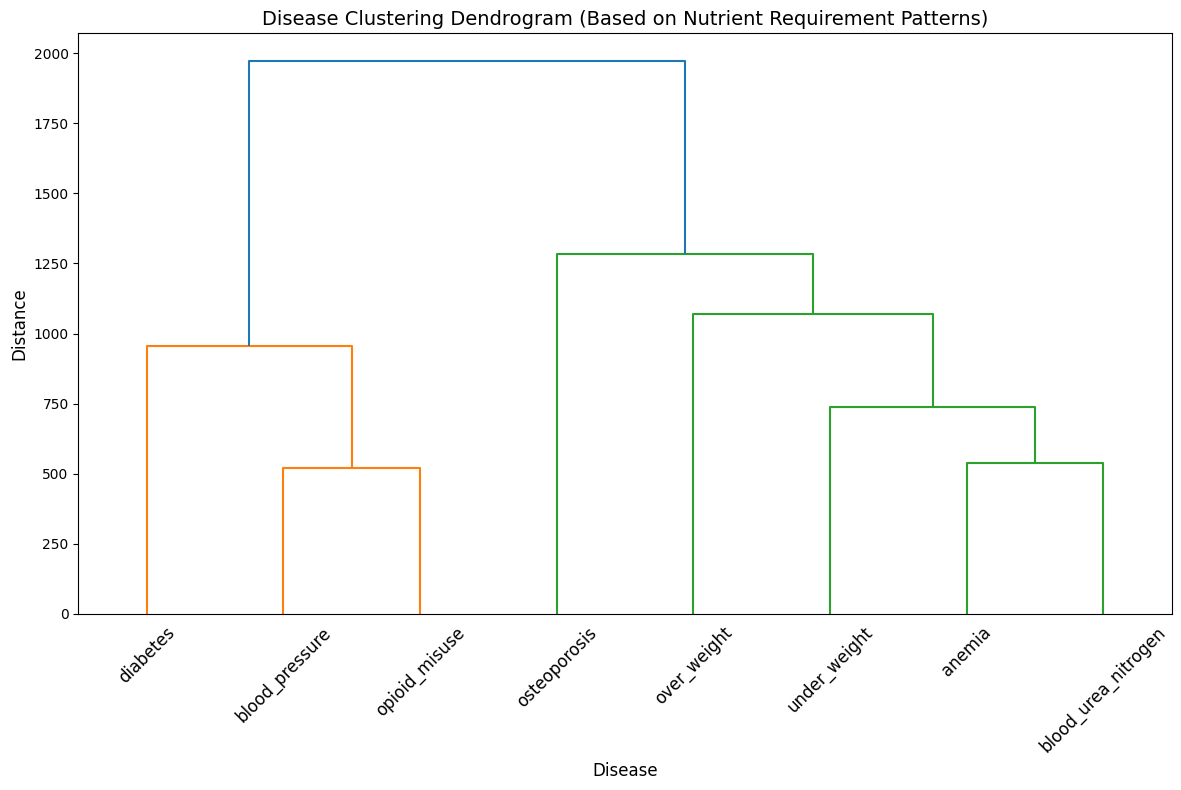

疾病聚类分析完成


In [6]:
from analysis.relative import disease_clustering_analysis
# 4. 疾病聚类
disease_clustering_analysis(analysis_data)

In [5]:
from analysis.relative import generate_association_report
# 6. 生成报告
generate_association_report(corr_df, diff_df)


关联性分析报告

--------------------------------------------------
1. 点二列相关分析
--------------------------------------------------

🔴 最强正相关 (患病 → 营养素摄入增加):
    osteoporosis ↔ vitamin_d: r=0.956 (p=0.0000e+00)
    blood_pressure ↔ potassium: r=0.559 (p=0.0000e+00)
    osteoporosis ↔ calcium: r=0.527 (p=0.0000e+00)
    osteoporosis ↔ vitamin_b12: r=0.497 (p=0.0000e+00)
    opioid_misuse ↔ protein: r=0.354 (p=0.0000e+00)
    anemia ↔ folic_acid: r=0.317 (p=0.0000e+00)
    over_weight ↔ protein: r=0.285 (p=0.0000e+00)
    opioid_misuse ↔ phosphorus: r=0.284 (p=0.0000e+00)
    blood_pressure ↔ vitamin_c: r=0.272 (p=0.0000e+00)
    over_weight ↔ phosphorus: r=0.253 (p=0.0000e+00)

🔵 最强负相关 (患病 → 营养素摄入减少):
    over_weight ↔ sugar: r=-0.772 (p=0.0000e+00)
    blood_pressure ↔ sodium: r=-0.731 (p=0.0000e+00)
    over_weight ↔ vitamin_c: r=-0.568 (p=0.0000e+00)
    blood_pressure ↔ folic_acid: r=-0.513 (p=0.0000e+00)
    diabetes ↔ carb: r=-0.475 (p=0.0000e+00)
    blood_pressure ↔ iron: r=-0.356 (p=0.00

,Disease,Most_Correlated_Nutrient,Correlation,Most_Different_Nutrient,Cohen_d,Diseased_Mean,Non_Diseased_Mean
0,under_weight,protein,-0.079,calorie,-1.022,1945.7,2554.7
1,over_weight,sugar,-0.772,sugar,-2.052,26.9,182.5
2,blood_pressure,sodium,-0.731,sodium,-1.964,1295.9,3783.2
3,diabetes,carb,-0.475,carb,-2.101,210.7,380.4
4,anemia,folic_acid,0.317,folic_acid,1.818,576.6,223.2
5,osteoporosis,vitamin_d,0.956,vitamin_d,9.030,20.4,0.5
6,opioid_misuse,protein,0.354,protein,1.127,85.3,59.9
7,blood_urea_nitrogen,carb,-0.139,carb,-0.425,328.0,370.7
